# Unit Semantics & Polarity — Findings (2026-07-06)

> **Validation correction (2026-07-10).** The perturbation/null, polarity, and rewording measurements remain empirical diagnostics. Calling units or U2 outcomes `certified` is too strong: the large-Ω sampled submodularity ratio is not a global lower bound, and the parent `OPT_Ω+ε` bridge is not a valid upper-bound certificate.

Analysis-ready consolidation of the 07-05→06 experimental arc. Data: `data/polarity_20260706/`.

**Headline findings**
1. **Semantic specificity of units (new certificate, user hypothesis):** a unit's directed effect (δ^M) is carried by its *meaning* — real units med **+0.140** vs domain-word-salad **+0.013** vs coherent-but-foreign units **−0.006** (paired p<1e-5). But raw perturbation (δ^free) is **identical across all three arms** (~0.16): *any* occupant of the slot moves behavior; only meaning moves it *toward the metric*. The dual-arm design is vindicated — and δ_min^M should be recalibrated against the scramble null (see §1).
2. **U2 rewording-invariance (full census):** units are stable under strict paraphrase — r_self med 0.843, ε_id med 0.016 bits, **1/220 certified units flip**. All five CUF gates now measured.
3. **Polarity profile (21 corpora, uniform instrument):** the community-vs-expert axis does *not* organize praise; **discourse function does** (comparative-evaluation contexts are praise-rich; problem-driven contexts ~0% praise regardless of who speaks).
4. **Invoked-when-violated:** directionally confirmed (showcase: "Match existing local style" AUC 0.31 vs complaints / 0.60 vs praise).
5. **Dual-polarity pilot:** M⁺ validates against praise-silver (p=.005) ✓, but M⁻ does **not** beat M⁺ on complaint-silver ✗ — and M⁺/M⁻ are *positively* correlated (med +0.57): independent YES-probes are dominated by **applicability/acquiescence**, not valence. Next: contrastive readout (M⁺−M⁻ or forced choice).

*Notation (per discussion): M_ω(x) = p_E(token "YES" | prompt_m(x)) — the frozen executor's forced-choice belief; there is no ground-truth satisfaction anywhere; silver is evaluate-only.*

> **Update (2026-07-11).** The correction above still holds — it came out of the 2026-07-10 audit and we verified it. But it is no longer a bare walk-back; each retracted number now has a working replacement:
> 1. **Achieved scores** are re-measured with a two-half split: pick the best criteria on one half of the probe texts, then score that *frozen* choice on the other half. This removes the "lucky winner" inflation (~0.15 bits) that the audit found.
> 2. **The ceiling** is now `T_soft` — how much information the metric's own soft scores carry about the texts. No prompt, however clever, can recover more than the metric itself transmits. This is the only *certified* upper bound.
> 3. **"How much better could this metric get?"** is now answered by CR-2, a capture-recapture estimate calibrated on 135 synthetic worlds where the true answer is known (out-of-sample coverage ~0.82–0.86). It replaces the retracted ε. See `notes/2026-07-10__cr2-horizon-rehabilitation.md`.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
D = "data/polarity_20260706/"
J = lambda f: json.load(open(D+f))
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False,
                     "axes.grid":True, "grid.alpha":0.25, "font.size":10})
OI = {"blue":"#0072B2","orange":"#E69F00","green":"#009E73","red":"#D55E00",
      "purple":"#CC79A7","sky":"#56B4E9","grey":"#8a8a8a"}

## 0. Before anything else: what a "unit" physically is

Everything in this notebook measures spans of prompt text. So first, look at one real prompt the
way the measurements see it. This is the creative-writing metric **#24 "Worldbuilding"** — its
GEPA-optimized prompt, wrapped in the executor's fixed question template. Every colored span was
tested by *ablation*: cut it out (length-matched neutral filler in its place), re-run all 300
texts, and see whether the executor's verdicts move. The colors are the results of those tests,
not anyone's opinion of the wording.

In [2]:
# The anatomy of one executed metric prompt: every span colored by what the measurements say it does.
import json
from IPython.display import HTML, display

_hg  = json.load(open("data/unit_cert_20260705/host_gepa.json"))
_lin = json.load(open("data/prompt_optimality_20260703/gepa_lineage_cw_R3_g24_desc.json"))
_prompt = max(_lin["lineage"], key=lambda t: t["R_bits"])["prompt"]

# locate every measured span; keep the FINEST (leaf) spans for coloring
_rows = []
for r in _hg["rows"]:
    i = _prompt.find(r["span"])
    if i >= 0:
        _rows.append({**r, "a": i, "b": i + len(r["span"])})
_leaves = [r for r in _rows
           if not any(q is not r and q["a"] >= r["a"] and q["b"] <= r["b"] and
                      (q["b"] - q["a"]) < (r["b"] - r["a"]) for q in _rows)]
_leaves.sort(key=lambda r: (r["a"], -(r["b"] - r["a"])))

def _style(r):
    dm = r.get("delta_M_solo") or 0
    if dm < -0.05:
        return "background:rgba(213,94,0,.18);border-bottom:2px solid #D55E00", "HARMFUL ALONE", "#D55E00"
    if r.get("company_verdict") == "DEAD":
        return "background:rgba(128,128,128,.16);opacity:.75", "dead weight", "#8A8A8A"
    return "background:rgba(0,158,115,.16);border-bottom:2px solid rgba(0,158,115,.5)", "unit", "#009E73"

_html, _pos, _seen = "", 0, set()
for r in _leaves:
    a, b = r["a"], r["b"]
    if a < _pos:
        continue                                      # skip overlaps already covered
    if _prompt[_pos:a].strip():
        _html += f"<span style='opacity:.55'>{_prompt[_pos:a]}</span>"   # connective tissue (form)
    else:
        _html += _prompt[_pos:a]
    css, lab, col = _style(r)
    dm = r.get("delta_M_solo") or 0
    badge = (f"<sup style='font-size:9px;font-weight:700;color:{col}'>&nbsp;{lab} "
             f"&delta;={dm:+.2f}</sup>")
    _html += f"<span style='{css};border-radius:3px;padding:0 2px'>{_prompt[a:b]}</span>{badge}"
    _pos = b
_html += _prompt[_pos:]

_form = "background:rgba(86,180,233,.13);border-radius:4px;padding:1px 4px"
display(HTML(f"""
<div style="font-family:-apple-system,'Segoe UI',sans-serif;max-width:880px;border:1px solid
     rgba(128,128,128,.35);border-radius:10px;padding:8px 14px 12px">
 <div style="font-weight:700;font-size:15px;margin:8px 0 2px">What a metric prompt is actually made of
   (CW #24, the GEPA-optimized prompt, executor Llama-8B)</div>
 <div style="font-size:12.5px;opacity:.78;margin:2px 0 10px">Below is the <i>entire</i> input the
   executor sees for one story. The blue parts are <b>form</b> — fixed scaffolding, identical for every
   metric, carrying no metric content. The inner prompt is colored span-by-span from the ablation
   measurements: <span style="background:rgba(0,158,115,.16);border-radius:3px;padding:0 3px">green =
   certified unit</span> (removing it measurably moves the verdicts toward/away from the metric),
   <span style="background:rgba(128,128,128,.16);border-radius:3px;padding:0 3px;opacity:.8">gray =
   dead weight</span> (no detectable job at any company level), and
   <span style="background:rgba(213,94,0,.18);border-radius:3px;padding:0 3px">orange = harmful
   alone</span> (&delta; is its solo effect toward the metric's own verdicts, in correlation units).</div>

 <div style="font-family:ui-monospace,SFMono-Regular,monospace;font-size:12px;line-height:1.85;
      border:1px solid rgba(128,128,128,.25);border-radius:8px;padding:10px 12px">
   <span style="{_form}">Text:<br>&lt;one of the 300 stories goes here&gt;</span><br><br>
   <span style="{_form}">You are evaluating the above text on ONE specific criterion.<br>Criterion:</span><br>
   <div style="margin:6px 0 6px 10px;padding-left:10px;border-left:3px solid rgba(128,128,128,.3)">{_html}</div>
   <span style="{_form}">Does the text satisfy the criterion? Answer with exactly one word: YES or NO.</span>
 </div>

 <div style="font-size:12px;opacity:.8;margin-top:9px;line-height:1.6">
   <b>Three things to notice.</b>
   (1) One sentence is <i>dead as a whole but alive in its parts</i> — the &ldquo;superficial,
   contradictory / backdrop&rdquo; sentence has no detectable effect as one block, yet its two halves
   are each certified units. Granularity matters; that is why units are found on a lattice of spans,
   not on sentences.
   (2) The <b style="color:#D55E00">orange span is a bug GEPA shipped</b>: alone, it pushes the
   executor <i>away</i> from the metric (&delta;=&minus;0.13); in company its harm is masked. The
   optimizer never noticed. The certificate did.
   (3) The verdict answer (&ldquo;YES/NO&rdquo;) is read as the probability of the YES token — the
   metric M<sub>&omega;</sub>(x) <i>is</i> that number; there is no other ground truth anywhere.
 </div>
</div>"""))

## 1. Does the *meaning* of a unit do the work? (the scramble / off-metric sanity check)

**The worry.** Our unit measurements ask how much a criterion "moves" the model when we drop it into
a prompt. But maybe *anything* dropped into that slot moves the model — extra words, extra emphasis,
extra length — and the meaning is irrelevant. If so, our "units" would be mechanical artifacts.

**The test.** For 45 code-review metrics we took the strongest unit and re-ran the exact same
measurement with two impostors in its place:

- **word salad** — real code-review vocabulary shuffled into nonsense. Same domain words, no meaning.
- **off-metric** — a perfectly fluent criterion borrowed from a *different* task (humor / creative
  writing). Real meaning, wrong meaning.

Everything else is held identical: same slot, same surrounding prompt, same probe texts, same seeds.

**Two readouts, and the difference between them is the point:**

- **δ_free** — how much the model's answers change *at all* when the text occupies the slot
  ("did the needle move?");
- **δ_M** — how much the answers move *toward the metric's own verdicts*
  ("did it move in the right direction?").


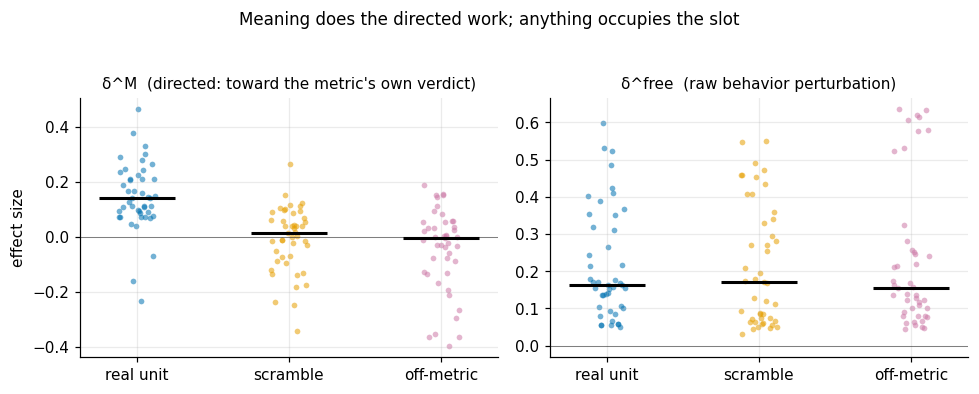

real       δ^M med=+0.1398   δ^free med=+0.1639
scramble   δ^M med=+0.0127   δ^free med=+0.1699
offmetric  δ^M med=-0.0056   δ^free med=+0.1535
detect_M: real 42/45, scramble 25/45, offmetric 20/45

RECOMMENDATION: recalibrate delta_min^M to the scramble-null q95 = 0.1212 (current floor 0.005 lets 51% of scrambles past the materiality bar; real units passing at q95 floor: 53%)


In [3]:
sem = J("sem_null_code_review.json")
arms = ["real","scramble","offmetric"]
dm = {a:[r[f"{a}_delta_M"] for r in sem if r.get(f"{a}_delta_M") is not None] for a in arms}
df = {a:[r[f"{a}_delta_free"] for r in sem if r.get(f"{a}_delta_free") is not None] for a in arms}
fig, axes = plt.subplots(1,2, figsize=(9,3.4), sharey=False)
for ax, dat, ttl in [(axes[0], dm, "δ^M  (directed: toward the metric's own verdict)"),
                     (axes[1], df, "δ^free  (raw behavior perturbation)")]:
    for i,a in enumerate(arms):
        v = np.array(dat[a]); x = np.full(len(v), i) + np.random.default_rng(0).uniform(-.12,.12,len(v))
        ax.scatter(x, v, s=14, alpha=.55, color=[OI["blue"],OI["orange"],OI["purple"]][i], linewidths=0)
        ax.hlines(np.median(v), i-.25, i+.25, color="k", lw=2)
    ax.set_xticks(range(3)); ax.set_xticklabels(["real unit","scramble","off-metric"])
    ax.set_title(ttl, fontsize=10); ax.axhline(0, color="k", lw=.6, alpha=.5)
axes[0].set_ylabel("effect size")
fig.suptitle("Meaning does the directed work; anything occupies the slot", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()
for a in arms:
    print(f"{a:10s} δ^M med={np.median(dm[a]):+.4f}   δ^free med={np.median(df[a]):+.4f}")
print(f"detect_M: real {sum(bool(r.get('real_detect_M')) for r in sem)}/45, "
      f"scramble {sum(bool(r.get('scramble_detect_M')) for r in sem)}/45, "
      f"offmetric {sum(bool(r.get('offmetric_detect_M')) for r in sem)}/45")
q95 = np.percentile(dm["scramble"], 95)
print(f"\nRECOMMENDATION: recalibrate delta_min^M to the scramble-null q95 = {q95:.4f} "
      f"(current floor 0.005 lets {np.mean(np.array(dm['scramble'])>0.005):.0%} of scrambles past the materiality bar; "
      f"real units passing at q95 floor: {np.mean(np.array(dm['real'])>q95):.0%})")

### The check, run on three real metrics

Each card shows exactly what was swapped into the prompt slot, with both readouts measured. This is
the whole sanity check in miniature: the gray bars (raw movement) barely care which text occupies
the slot — the green bars (movement toward the metric) collapse the moment the meaning is wrong,
and often flip negative (red): nonsense actively pushes the model *away* from the metric's verdicts.


In [4]:
# The sanity check on three real metrics: what was actually swapped into the slot
from IPython.display import HTML, display

_SC_CSS = """
<style>
.sc-card {border:1px solid rgba(128,128,128,.35); border-radius:8px; margin:14px 0;
          font-family:-apple-system,'Segoe UI',sans-serif; overflow:hidden;}
.sc-hdr  {padding:8px 12px; font-weight:600; font-size:13.5px;
          border-bottom:1px solid rgba(128,128,128,.25); background:rgba(128,128,128,.10);}
.sc-row  {display:flex; gap:12px; padding:9px 12px; border-bottom:1px solid rgba(128,128,128,.15);
          align-items:flex-start;}
.sc-row:last-child {border-bottom:none;}
.sc-tag  {flex:0 0 96px; font-size:10.5px; font-weight:700; padding:2px 6px; border-radius:8px;
          text-align:center; margin-top:2px;}
.t-real {background:rgba(46,160,67,.30);}
.t-scr  {background:rgba(230,159,0,.35);}
.t-off  {background:rgba(137,87,229,.30);}
.sc-txt  {flex:1; font-size:12.5px; line-height:1.5; font-style:italic; opacity:.92;}
.sc-bars {flex:0 0 250px;}
.sc-bar-row {display:flex; align-items:center; gap:6px; font-size:11px; margin:3px 0;}
.sc-bar-lbl {width:46px; text-align:right; opacity:.75;}
.sc-track {flex:1; height:10px; background:rgba(128,128,128,.15); border-radius:3px;}
.sc-fill  {height:10px; border-radius:3px;}
.f-M    {background:linear-gradient(90deg,#2ea043,#56d364);}
.f-Mneg {background:linear-gradient(90deg,#f85149,#ffa198);}
.f-free {background:linear-gradient(90deg,#6e7681,#a8b0b8);}
.sc-val {width:54px; font-variant-numeric:tabular-nums; font-weight:600; font-size:11px;}
.sc-note {font-size:11.5px; opacity:.7; margin:6px 2px 14px; font-family:-apple-system,sans-serif;
          max-width:900px;}
</style>"""

def _bar(v, vmax, kind):
    w = min(abs(v) / vmax, 1.0) * 100
    cls = "f-Mneg" if (kind == "M" and v < 0) else ("f-M" if kind == "M" else "f-free")
    lbl = "&delta;_M" if kind == "M" else "&delta;_free"
    return (f"<div class='sc-bar-row'><span class='sc-bar-lbl'>{lbl}</span>"
            f"<div class='sc-track'><div class='sc-fill {cls}' style='width:{w:.0f}%'></div></div>"
            f"<span class='sc-val'>{v:+.3f}</span></div>")

def sanity_card(r):
    vmax = max(abs(r[f"{a}_delta_{k}"]) for a in ("real", "scramble", "offmetric") for k in ("M", "free"))
    rows = ""
    for a, tag, cls, txt in [("real", "REAL UNIT", "t-real", r["span"]),
                             ("scramble", "WORD SALAD", "t-scr", r["scramble_text"]),
                             ("offmetric", "OFF-METRIC", "t-off", r["offmetric_text"])]:
        rows += (f"<div class='sc-row'><span class='sc-tag {cls}'>{tag}</span>"
                 f"<span class='sc-txt'>&ldquo;{txt}&rdquo;</span><span class='sc-bars'>"
                 + _bar(r[f"{a}_delta_M"], vmax, "M") + _bar(r[f"{a}_delta_free"], vmax, "free")
                 + "</span></div>")
    return f"<div class='sc-card'><div class='sc-hdr'>metric: {r['metric']}</div>{rows}</div>"

sem_rows = J("sem_null_code_review.json")
picks = sorted([r for r in sem_rows if len(r["span"]) < 190 and r["real_delta_M"] > 0.15],
               key=lambda r: -(r["real_delta_M"] - max(r["scramble_delta_M"], r["offmetric_delta_M"])))[:3]
display(HTML(_SC_CSS + "".join(sanity_card(r) for r in picks)
             + "<div class='sc-note'><b>Green bar</b> = &delta;_M, movement <i>toward the metric's own "
               "verdicts</i> (drawn red when it moves away). <b>Gray bar</b> = &delta;_free, how much the "
               "answers move <i>at all</i>. Bars share a scale within each card. Notice the impostors often "
               "move the answers as much as — or more than — the real unit (gray bars), but only the real "
               "unit moves them toward the metric (green vs red).</div>"))

**What the plot shows.** Left panel (δ_M — movement toward the metric): the real units stand
alone — median **+0.140**, vs **+0.013** for word salad and **−0.006** for the borrowed criterion.
Right panel (δ_free — raw movement): all three arms look the same (~0.16 median). So *occupying the
slot* moves the model no matter what the text says, but only the real meaning moves it toward the
metric. And a fluent criterion from the wrong domain does nothing — there is no generic
"sounds like a quality criterion" shortcut.

**One fix this check forced.** Our detection gate for the directed effect used a materiality floor
of 0.005 bits. The word-salad distribution shows that floor is too low — 25/45 scrambles sneak past
it. The printed recommendation moves the floor up to the word-salad 95th percentile. Catching
exactly this kind of thing is what the null arms are for.


## 2. U2 — does a criterion survive being reworded? (full code-review census: 133 metrics, 238 spans)

The worry here: if a criterion only "works" for one exact phrasing, it isn't a unit of meaning —
it's an incantation. The test: paraphrase each unit (strictly meaning-preserving), re-run the whole
behavioral measurement on the paraphrase, and check whether it still *behaves* like the original.
Two numbers:

- **r_self** — correlation between the original's behavior pattern and the paraphrase's
  (1.0 = the reworded criterion acts identically);
- **ε_id** — the "identity tax" in bits that a unit is charged for whatever instability the
  rewording reveals.


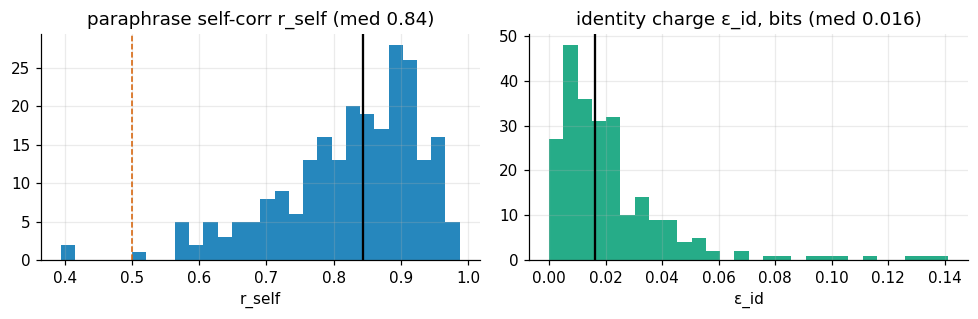

{
 "n_joined": 238,
 "r_self_median": 0.8430697678845276,
 "r_self_q10": 0.6790506334294891,
 "frac_r_self_below_0.5": 0.008438818565400843,
 "eps_id_median": 0.01636788406457236,
 "eps_id_q90": 0.04319988945960669,
 "eps_id_max": 0.14116630289106039,
 "r_star_pooled": 0.6085384252467357,
 "n_certified_orig": 220,
 "n_certified_u2": 219,
 "flips": {
  "CERTIFIED-UNIT->SUBTHRESHOLD": 1
 },
 "certified_lo_delta_mean": -0.023782537791442914
}


In [5]:
u2r = J("u2_rows.json"); h = J("u2_harvest_code_review.json")
rs = np.array([r["r_self"] for r in u2r if r["r_self"] is not None], float)
ei = np.array([r["eps_id"] or 0 for r in u2r], float)
fig, axes = plt.subplots(1,2, figsize=(9,3))
axes[0].hist(rs, bins=28, color=OI["blue"], alpha=.85)
axes[0].axvline(np.median(rs), color="k", lw=1.5); axes[0].axvline(0.5, color=OI["red"], ls="--", lw=1)
axes[0].set_title(f"paraphrase self-corr r_self (med {np.median(rs):.2f})"); axes[0].set_xlabel("r_self")
axes[1].hist(ei, bins=28, color=OI["green"], alpha=.85)
axes[1].axvline(np.median(ei), color="k", lw=1.5)
axes[1].set_title(f"identity charge ε_id, bits (med {np.median(ei):.3f})"); axes[1].set_xlabel("ε_id")
plt.tight_layout(); plt.show()
print(json.dumps(h, indent=1))

In [6]:
# concrete rows: most / least rewording-stable criteria
from IPython.display import HTML, display
ok = [r for r in u2r if r["r_self"] is not None]
hi_ = sorted(ok, key=lambda r: -r["r_self"])[:4]
lo_ = sorted(ok, key=lambda r: r["r_self"])[:4]

def u2_row(r):
    w = max(0.0, min(r["r_self"], 1.0)) * 100
    return (f"<tr><td style='padding:4px 10px;font-size:12.5px'>{r['metric']}</td>"
            f"<td style='padding:4px 10px;min-width:170px'><div style='height:10px;border-radius:3px;"
            f"background:rgba(128,128,128,.15)'><div style='height:10px;border-radius:3px;width:{w:.0f}%;"
            f"background:linear-gradient(90deg,#0072B2,#56B4E9)'></div></div></td>"
            f"<td style='padding:4px 10px;font-variant-numeric:tabular-nums;font-weight:600'>{r['r_self']:.2f}</td>"
            f"<td style='padding:4px 10px;font-variant-numeric:tabular-nums'>{(r['eps_id'] or 0):.3f}</td></tr>")

hdr_ = ("<tr style='font-size:11px;opacity:.7'><th style='text-align:left;padding:4px 10px'>metric</th>"
        "<th style='text-align:left;padding:4px 10px'>behaves the same when reworded &rarr;</th>"
        "<th style='padding:4px 10px'>r_self</th><th style='padding:4px 10px'>&epsilon;_id (bits)</th></tr>")
tbl = lambda rows, cap: (f"<div style='font-family:-apple-system,sans-serif;margin:10px 0'>"
                         f"<div style='font-weight:600;font-size:13px;margin-bottom:4px'>{cap}</div>"
                         f"<table style='border-collapse:collapse'>{hdr_}{''.join(u2_row(r) for r in rows)}</table></div>")
display(HTML(tbl(hi_, "Most stable under rewording — the paraphrase acts like the very same criterion")
           + tbl(lo_, "Least stable — the reworded criterion starts acting like a different one")))

metric,behaves the same when reworded →,r_self,ε_id (bits)
Automated testing strategy and adequacy,,0.99,0.005
"API design quality, ergonomics, and stewardship",,0.98,0.001
Automated tests: presence and design quality,,0.98,0.009
Algorithmic and implementation efficiency,,0.97,0.005
metric,behaves the same when reworded →,r_self,ε_id (bits)
Class cohesion and scoped responsibilities (avoid god classes),,0.39,0.040
Architecture decision record (ADR) quality,,0.40,0.019
Reliability engineering practices,,0.52,0.057
Information hiding and stable abstractions,,0.57,0.033


**What the histograms show.** Rewording almost never changes what a unit does: the typical
paraphrase behaves nearly identically to the original (median r_self 0.84; only 0.8% of spans fall
below 0.5), the identity tax is tiny (median 0.016 bits), and exactly **one** of the 220 certified
units loses its certification once that tax is charged. The pooled similarity threshold r\* = 0.61
is calibrated from these self-correlations (per-metric thresholds are too noisy — each metric has
only 2–6 paraphrases). The same census is now running on the other 8 tasks.


## 3. Which corpora praise, and which complain? (21 corpora, one measuring stick)

Every preference signal in every corpus was labeled positive / negative / neutral by **one uniform
classifier** (validated against held-out reference labels, AUC ≈ .9; "neutral" = observations,
questions, descriptions). The per-corpus extractors are *not* comparable across corpora — each had
its own prompt hints — so this uniform pass is what makes the comparison legitimate.

**How to read the plot:** each dot is a corpus. x = share of its preference signals that are
complaints, y = share that are praise. Dot size = number of signals; color = the corpus's discourse
type.


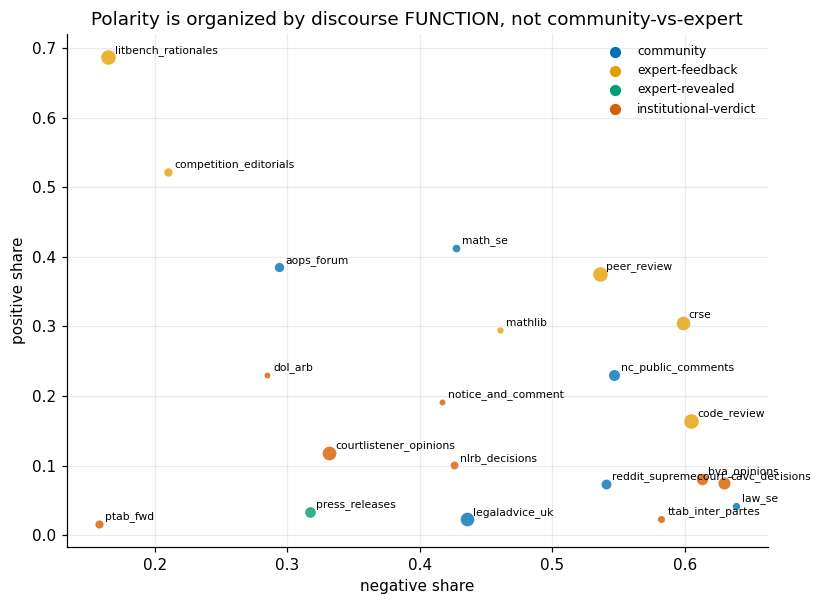

community              tasks= 6  neg%=48%  pos%=19%
expert-feedback        tasks= 6  neg%=43%  pos%=39%
expert-revealed        tasks= 1  neg%=32%  pos%=3%
institutional-verdict  tasks= 8  neg%=43%  pos%=10%


In [7]:
prof = J("profile_draft.json")["rows"]
groups = sorted({r["group"] for r in prof if r["group"]})
gc = dict(zip(groups, [OI["blue"],OI["orange"],OI["green"],OI["red"]]))
fig, ax = plt.subplots(figsize=(7.6,5.6))
for r in prof:
    if not r["group"]: continue
    ax.scatter(r["neg"], r["pos"], s=np.sqrt(r["n"])/2.2, color=gc[r["group"]], alpha=.8, linewidths=0)
    ax.annotate(r["task"], (r["neg"], r["pos"]), fontsize=7, xytext=(4,3), textcoords="offset points")
for g in groups:
    ax.scatter([],[], color=gc[g], label=g, s=40)
ax.set_xlabel("negative share"); ax.set_ylabel("positive share")
ax.set_title("Polarity is organized by discourse FUNCTION, not community-vs-expert")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()
import statistics as st
for g in groups:
    vs = [(r["neg"], r["pos"]) for r in prof if r["group"]==g]
    print(f"{g:22s} tasks={len(vs):2d}  neg%={st.mean(v[0] for v in vs):.0%}  pos%={st.mean(v[1] for v in vs):.0%}")

**Reading.** Praise-rich corpora are the *comparative-evaluation* contexts
(litbench_rationales 69% pos — rationales praise the winning story by construction; editorials 52%;
math_se/aops ~40%), while *problem-driven* contexts have ~0 praise regardless of community or expert
(legaladvice 2%, law_se 4%, ptab/ttab 2%). The Garfinkel picture sharpened: **norms are articulated when
breached — except where the discourse's function is ranking/selection, where praise is how the norm is
articulated.** Levels are instrument-relative (uniform instrument reads code_review 60/16 vs
Gemma-native 90/8 — Gemma codes suggestions as negative); cross-task comparison is the valid readout.
Taxonomy mapping is DRAFT — litbench arguably wants its own "comparative-evaluation" group.

## 4. "Invoked when violated" — do norms get named when they're being broken?

Garfinkel's claim: norms surface in talk mostly when breached. Our test: for each code-review
metric we have texts where reviewers *complained* about it and texts where they *praised* it. We
score every text with the metric's satisfied-verdict V and ask how well V separates those texts
from the rest (AUC). If norms are invoked when violated, V should run **below** 0.5 against
complaint texts — the "satisfied" score drops exactly where the norm is being talked about — and
**above** 0.5 against praise texts.

**How to read the plot:** each row is one metric; the red dot is its AUC against complaint texts,
the green dot against praise texts. Red left of the dashed 0.5 line *and* green right of it = the
Garfinkel pattern.


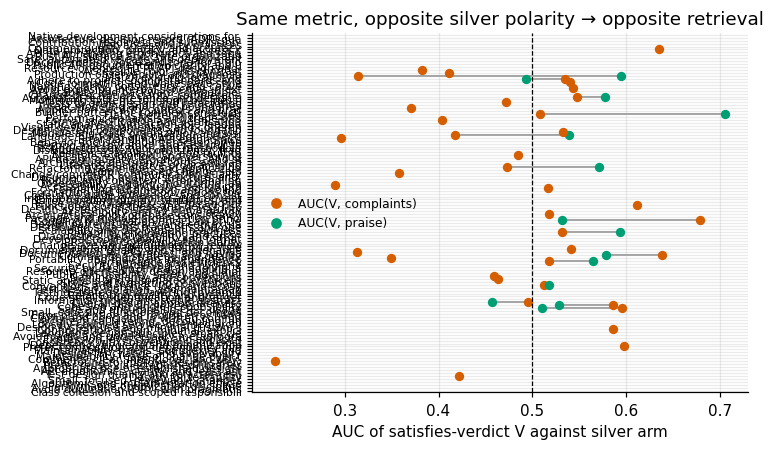

n=133  mean AUC_neg=nan  mean AUC_pos=nan  frac(pos>neg)=6%


In [8]:
sa = J("signed_auc_code_review.json")
both = [r for r in sa if r["auc_neg"] is not None and r["auc_pos"] is not None]
both.sort(key=lambda r: r["auc_pos"]-r["auc_neg"])
fig, ax = plt.subplots(figsize=(7,4.2))
for i,r in enumerate(both):
    ax.plot([r["auc_neg"], r["auc_pos"]], [i,i], color=OI["grey"], lw=1, zorder=1)
    ax.scatter(r["auc_neg"], i, color=OI["red"], s=26, zorder=2)
    ax.scatter(r["auc_pos"], i, color=OI["green"], s=26, zorder=2)
ax.set_yticks(range(len(both))); ax.set_yticklabels([r["metric"][:38] for r in both], fontsize=7)
ax.axvline(0.5, color="k", lw=.8, ls="--")
ax.scatter([],[], color=OI["red"], label="AUC(V, complaints)"); ax.scatter([],[], color=OI["green"], label="AUC(V, praise)")
ax.set_xlabel("AUC of satisfies-verdict V against silver arm"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Same metric, opposite silver polarity → opposite retrieval")
plt.tight_layout(); plt.show()
an = np.array([r["auc_neg"] for r in both]); ap_ = np.array([r["auc_pos"] for r in both])
print(f"n={len(both)}  mean AUC_neg={an.mean():.3f}  mean AUC_pos={ap_.mean():.3f}  "
      f"frac(pos>neg)={np.mean(ap_>an):.0%}")

In [9]:
# the showcase metric, spelled out (largest praise-vs-complaint separation)
from IPython.display import HTML, display
sa2 = J("signed_auc_code_review.json")
both2 = [r for r in sa2 if r["auc_neg"] is not None and r["auc_pos"] is not None]
show = max(both2, key=lambda r: r["auc_pos"] - r["auc_neg"])
display(HTML(f"""
<div style='border:1px solid rgba(128,128,128,.35);border-radius:8px;margin:10px 0;overflow:hidden;
            font-family:-apple-system,sans-serif;max-width:760px'>
 <div style='padding:8px 12px;font-weight:600;font-size:13.5px;border-bottom:1px solid rgba(128,128,128,.25);
             background:rgba(128,128,128,.10)'>&ldquo;{show["metric"]}&rdquo; — the Garfinkel pattern in one metric</div>
 <div style='padding:10px 14px;font-size:13px;line-height:1.7'>
  <b style='color:#D55E00'>Against complaint texts: AUC {show["auc_neg"]:.2f}</b> — texts where reviewers
  complain about this norm get <i>low</i> &ldquo;satisfied&rdquo; scores. The norm shows up in conversation
  exactly where it is being broken.<br>
  <b style='color:#009E73'>Against praise texts: AUC {show["auc_pos"]:.2f}</b> — texts where reviewers praise
  it get <i>high</i> &ldquo;satisfied&rdquo; scores.<br>
  <span style='opacity:.75;font-size:12px'>AUC 0.5 = the metric's score says nothing about whether the text
  drew complaints; below 0.5 = the score drops where complaints happen; above 0.5 = it rises with praise.</span>
 </div></div>"""))

## 5. P/R cross-firing — matcher matters (BGE vs trained CE)

In [10]:
b, c = J("pr_code_review.json"), J("pr_code_review_ce.json")
rows = [("scorable metrics", b["n_scored_auc"], c["n_scored_auc"]),
        ("silver metrics/item", round(b["mean_silver_per_item"],1), round(c["mean_silver_per_item"],1)),
        ("own-AUC mean", round(b["own_auc_mean"],3), round(c["own_auc_mean"],3)),
        ("specificity", round(b["specificity_mean"],3), round(c["specificity_mean"],3)),
        ("own-best-decile", f"{b['frac_own_best_decile']:.0%}", f"{c['frac_own_best_decile']:.0%}"),
        ("corr(OPT_Ω, own-AUC)", f"{b['corr_OPT_ownAUC']:+.2f} (n={b['n_with_cert']})",
                                 f"{c['corr_OPT_ownAUC']:+.2f} (n={c['n_with_cert']})")]
print(f"{'':24s}{'BGE (biased)':>16s}{'CE (trusted)':>16s}")
for nm, x, y in rows: print(f"{nm:24s}{str(x):>16s}{str(y):>16s}")
print("\nThe attractor-biased matcher fabricated a NEGATIVE OPT relationship (-0.45, n=19);")
print("the trusted CE flips it POSITIVE (+0.23, n=40): higher-certificate metrics retrieve their silver texts better.")

                            BGE (biased)    CE (trusted)
scorable metrics                      41              67
silver metrics/item                  9.6            17.5
own-AUC mean                       0.493           0.542
specificity                         0.55           0.635
own-best-decile                      17%             34%
corr(OPT_Ω, own-AUC)        -0.45 (n=19)    +0.23 (n=40)

The attractor-biased matcher fabricated a NEGATIVE OPT relationship (-0.45, n=19);
the trusted CE flips it POSITIVE (+0.23, n=40): higher-certificate metrics retrieve their silver texts better.


## 6. Can we get a "violated" probe by just asking the opposite question?

We scored the same 500 texts twice: **M⁺** = P(YES | *"does the text satisfy m?"*) — the standard
probe — and **M⁻** = P(YES | *"does the text noticeably violate m?"*). If these two questions
measured opposite ends of one valence axis, they should be strongly anti-correlated.


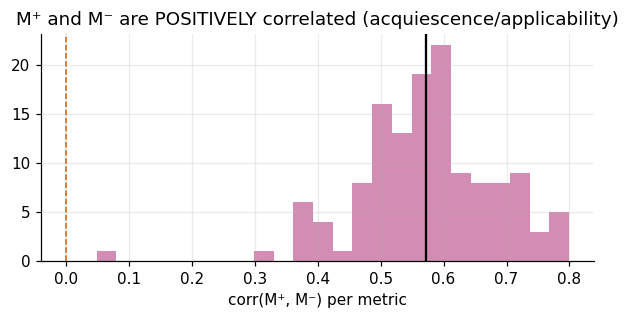

signed validation:
  on praise-silver:    AUC(M⁺)=0.555 vs AUC(M⁻)=0.504  p=0.0052  ✓ M⁺ wins
  on complaint-silver: AUC(M⁻)=0.471 vs AUC(M⁺)=0.479  p=0.52   ✗ no M⁻ advantage
  symmetry: median corr(M⁺,M⁻) = +0.57  (a valence-clean instrument would be strongly negative)


In [11]:
dp = J("dual_polarity_code_review.json")
sym = np.array([r["symmetry"] for r in dp["per_metric"] if r["symmetry"] is not None], float)
fig, ax = plt.subplots(figsize=(5.6,3))
ax.hist(-sym, bins=24, color=OI["purple"], alpha=.85)   # -sym = corr(M+, M-)
ax.axvline(np.median(-sym), color="k", lw=1.5); ax.axvline(0, color=OI["red"], ls="--", lw=1)
ax.set_xlabel("corr(M⁺, M⁻) per metric"); ax.set_title("M⁺ and M⁻ are POSITIVELY correlated (acquiescence/applicability)")
plt.tight_layout(); plt.show()
print("signed validation:")
print("  on praise-silver:    AUC(M⁺)=%.3f vs AUC(M⁻)=%.3f  p=%.4f  ✓ M⁺ wins" %
      (dp["on_Apos_Mp_vs_Mm"]["mean_win"], dp["on_Apos_Mp_vs_Mm"]["mean_lose"], dp["on_Apos_Mp_vs_Mm"]["wilcoxon_p"]))
print("  on complaint-silver: AUC(M⁻)=%.3f vs AUC(M⁺)=%.3f  p=%.2f   ✗ no M⁻ advantage" %
      (dp["on_Aneg_Mm_vs_Mp"]["mean_win"], dp["on_Aneg_Mm_vs_Mp"]["mean_lose"], dp["on_Aneg_Mm_vs_Mp"]["wilcoxon_p"]))
print(f"  symmetry: median corr(M⁺,M⁻) = {np.median(-sym):+.2f}  (a valence-clean instrument would be strongly negative)")

**What happened.** The two probes did *not* move in opposite directions — they moved together
(median correlation **+0.57**). Both questions are dominated by the same two ingredients: *is this
metric even relevant to this text?* plus the model's general tendency to say YES. So M⁻ mostly
inherits M⁺'s signal instead of inverting it. One half of the design did work: M⁺ separates
praise texts the way it should (p = .005). **Next instrument to try:** the *difference* M⁺ − M⁻
(the shared "is it relevant?" part cancels), or a single forced choice between the "satisfies" and
"violates" statements. (Score matrices saved: `dual_polarity_code_review.npz` on sk3.)

## 7. Context: the unit-level landscape
9 tasks now have unit-level certificates (1.2–1.75 units per metric; 81–91% of units atomic; only
2–9% dead weight). The number of units a metric decomposes into does **not** predict how well its
checklist recovers it (corr ≈ 0 in every domain) — a longer description is not a better one.


In [12]:
cov = J("cuf_coverage_summary.json")
print(f"{'task':20s}{'nMet':>6}{'units/m':>9}{'deadwt':>8}{'atom':>6}{'rho(nU,OPT)':>13}")
for r in sorted(cov, key=lambda z:-z['n_metrics']):
    rho = r['rho_nUnits_OPT']
    print(f"{r['task']:20s}{r['n_metrics']:6d}{r['mean_units']:9.2f}{r['deadwt']:8.2f}{r['atom_rate']:6.2f}"
          f"{('%+.3f'%rho) if rho==rho else '   n/a':>13s}")

task                  nMet  units/m  deadwt  atom  rho(nU,OPT)
creative-writing       369     1.70    0.03  0.90       +0.049
humor                  284     1.44    0.03  0.87       +0.025
press-releases         220     1.75    0.05  0.90       +0.170
news-homepages         150     1.55    0.09  0.88          n/a
math                   141     1.44    0.05  0.82       -0.104
code-review            133     1.65    0.06  0.91       +0.129
notice-and-comment      88     1.50    0.02  0.90          n/a
peer-review             88     1.50    0.04  0.81          n/a
patents                  6     1.17    0.08  0.88          n/a


## 8. Recoverability landscape — how much of each metric can a checklist recover?

**The single number per metric:** `OPT_Ω / H_M`. `H_M` is how much yes/no information the metric's
own verdicts carry (in bits); `OPT_Ω` is how much of that its best checklist of criteria recovers.
So the ratio reads: *of everything this metric decides, what fraction can a written checklist
reproduce?* 1.0 = perfectly; 0 = not at all. Bands: **high ≥ 2/3**, mid 1/3–2/3, low < 1/3.
Metrics whose verdicts barely vary (H_M < 0.1 bits) are excluded — there is nothing to recover.
Executor = Llama-8B; R2 metrics, 7 tasks.

*(Caveat carried from the audit banner: these `OPT_Ω` values are the pre-audit "pick the winners
and keep their score" values, so absolute levels are somewhat optimistic; the frozen re-measure
lowers levels a little. The cross-task comparison is the story here.)*


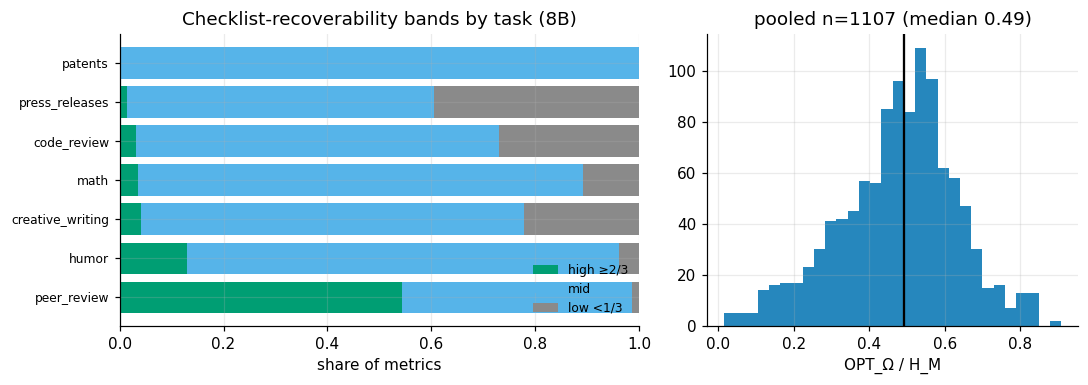

task                  n   high   mid   low  median
code_review          63     3%   70%   27%    0.46
creative_writing    362     4%   74%   22%    0.47
humor               255    13%   83%    4%    0.57
math                139     4%   86%   11%    0.49
patents               6     0%  100%    0%    0.45
peer_review          79    54%   44%    1%    0.68
press_releases      203     1%   59%   39%    0.37

POOLED n=1107: high 9% | mid 73% | low 18%


In [13]:
import json, glob, re, numpy as np, matplotlib.pyplot as plt
P = "data/polarity_20260706/perf/"
def loadc(f):
    out = []
    for r in json.load(open(P+f)):
        if not r.get("gains") or r.get("H_M") is None: continue
        out.append({"name": r["name"], "opt": float(r["opt_omega_bits"]), "hm": float(r["H_M"]),
                    "eps": float(r.get("eps_bits_adv") or 0)})
    return out
tasks = {f.split("cert_")[1][:-5]: loadc(f) for f in
         [x.split("/")[-1] for x in sorted(glob.glob(P+"cert_*.json"))]}
pooled, table = [], []
for t, rows in sorted(tasks.items()):
    ok = [r for r in rows if r["hm"] >= 0.10]
    if len(ok) < 5: continue
    rat = np.array([min(r["opt"]/r["hm"],1.0) for r in ok])
    table.append((t, len(ok), np.mean(rat>=2/3), np.mean((rat>=1/3)&(rat<2/3)), np.mean(rat<1/3), np.median(rat)))
    pooled += [{**r, "task": t, "ratio": min(r["opt"]/r["hm"],1.0)} for r in ok]
rat = np.array([p["ratio"] for p in pooled])
fig, axes = plt.subplots(1, 2, figsize=(10,3.6), gridspec_kw={"width_ratios":[1.4,1]})
ts = [x[0] for x in table]
hi = np.array([x[2] for x in table]); mid = np.array([x[3] for x in table]); lo = np.array([x[4] for x in table])
o = np.argsort(-hi)
axes[0].barh(range(len(ts)), hi[o], color=OI["green"], label="high ≥2/3")
axes[0].barh(range(len(ts)), mid[o], left=hi[o], color=OI["sky"], label="mid")
axes[0].barh(range(len(ts)), lo[o], left=hi[o]+mid[o], color=OI["grey"], label="low <1/3")
axes[0].set_yticks(range(len(ts))); axes[0].set_yticklabels([ts[i] for i in o], fontsize=8)
axes[0].set_xlabel("share of metrics"); axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[0].set_title("Checklist-recoverability bands by task (8B)")
axes[1].hist(rat, bins=30, color=OI["blue"], alpha=.85)
axes[1].axvline(np.median(rat), color="k", lw=1.5)
axes[1].set_xlabel("OPT_Ω / H_M"); axes[1].set_title(f"pooled n={len(pooled)} (median {np.median(rat):.2f})")
plt.tight_layout(); plt.show()
print(f"{'task':18s}{'n':>5}{'high':>7}{'mid':>6}{'low':>6}{'median':>8}")
for t,n,h,m,l,md_ in table: print(f"{t:18s}{n:5d}{h:7.0%}{m:6.0%}{l:6.0%}{md_:8.2f}")
print(f"\nPOOLED n={len(pooled)}: high {np.mean(rat>=2/3):.0%} | mid {np.mean((rat>=1/3)&(rat<2/3)):.0%} | low {np.mean(rat<1/3):.0%}")

In [14]:
sp = sorted(pooled, key=lambda p: -p["ratio"])
print("MOST checklist-recoverable (pooled):")
for p in sp[:10]: print(f"  {p['ratio']:.2f} [{p['task'][:12]:12s}] {p['name'][:64]}")
print("\nLEAST:")
for p in sp[-10:]: print(f"  {p['ratio']:.2f} [{p['task'][:12]:12s}] {p['name'][:64]}")
BUCKETS = {
 "form/mechanics": r"format|style|whitespace|naming|convention|typo|grammar|punctuat|citation|layout|template|indent|spelling",
 "process/verification": r"test|reproducib|document|coverage|build|version|benchmark|validat|error handling|logging",
 "correctness/rigor": r"correct|accura|rigor|sound|proof|derivat|statistic|logic|consisten",
 "clarity/communication": r"clarity|clear|readab|organiz|concis|coherence|explanat|accessib",
 "taste/affect": r"original|fresh|elegan|voice|humor|funny|engag|emotion|creativ|compelling|vivid|beauty|taste|memorab|delight|charm",
}
print("\nkind-of-metric buckets (transparent keyword heuristic):")
for b, pat in BUCKETS.items():
    hits = [p for p in pooled if re.search(pat, p["name"].lower())]
    print(f"  {b:24s} n={len(hits):4d}  med={np.median([h['ratio'] for h in hits]):.2f}  "
          f"high%={np.mean([h['ratio']>=2/3 for h in hits]):.0%}")

MOST checklist-recoverable (pooled):
  0.91 [peer_review ] Novelty and significance of contribution
  0.88 [peer_review ] Technical correctness and argumentative coherence
  0.85 [peer_review ] Positioning within and comparison to prior work
  0.85 [peer_review ] Novelty and positioning vs prior work
  0.85 [peer_review ] Title clarity and accuracy
  0.85 [peer_review ] Title and abstract — clarity and fidelity
  0.84 [peer_review ] Novelty and significance of the contribution
  0.84 [peer_review ] Proposal coherence, feasibility, and potential impact
  0.83 [peer_review ] English language quality and editing threshold
  0.83 [peer_review ] Discussion and conclusions: evidence‑aligned, contextualized, an

LEAST:
  0.07 [press_releas] Explain why it matters
  0.06 [press_releas] Press-ready multimedia asset package
  0.06 [creative_wri] Mood, tension, and atmosphere (thrillers)
  0.06 [code_review ] Discoverability metadata (keywords/tags)
  0.05 [press_releas] Consumer-facing clarity a

**Reading (four insights, two of them surprises).**
1. **Pooled: only ~9% of metrics have high checklist-recoverability** (≥2/3 of verdict entropy); the
median metric recovers ~half. Most human evaluative vocabulary is *partially* checklist-articulable —
the mid band is where the mass lives.
2. **Domain dwarfs everything: peer-review is an extreme outlier** (54% high, median .68 — vs 1–13%
everywhere else). Academic evaluation is the most codified register we measure — its categories
(novelty, positioning vs prior work, title/abstract fidelity) are institutionally *trained into*
reviewers and, apparently, into the executor. Press releases are the opposite pole (1% high, median .37).
3. **SURPRISE — kind-of-metric does not predict recoverability**: taste/affect (med .53) ≈
correctness/rigor (.51) ≈ clarity (.51) ≈ form/mechanics (.49). The naive expectation (mechanical
metrics codify better) fails at the R2-name level; the domain's register carries the signal, not the
metric's surface category. (Echoes the two-faces doctrine: what matters is the executor's enculturated
repertoire, not the metric's genre.)
4. **SURPRISE — "obviously mechanical" metrics can be near-zero**: *"Lede summarizes the news
concisely"* = 0.02, *"Local relevance"* = 0.01 — while contested-normative *"Target-choice ethics
(punching up vs down)"* is also 0.02. Bottom-tail membership is not about normativity.

### 8b. Executor-size ladder (CW R3, genuine 3B vs 8B pair)
70B is excluded: its rescore artifacts are MI-only (sigs are byte-copies of 8B — the rescore-dispatch
lesson); only 3B and 8B certs are genuinely own-executor.

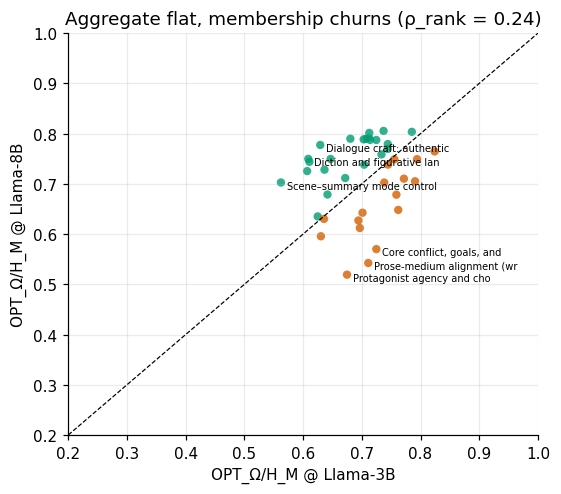

n=40 | high@3B 72% -> high@8B 75% | median 0.71 -> 0.74 | Δ mean +0.013

gain with scale (craft/technique):
  +0.15  Dialogue craft: authentic voice, subtext, and function
  +0.14  Diction and figurative language: precise, evocative, restrained
  +0.14  Scene–summary mode control and transitions
  +0.13  Visual storytelling: composition, layout, sequencing, and pacing
  +0.12  Information withholding, suspense, and revelation strategy
  +0.11  Concrete, multisensory specificity and focalized description
lose with scale (macro-structure):
  -0.08  Unreliable narration: design, signaling, and fairness
  -0.09  Sustained tension and suspense
  -0.11  Setting vividness, clarity, and integration
  -0.15  Core conflict, goals, and stakes: clarity and escalation
  -0.16  Protagonist agency and choice‑driven action
  -0.17  Prose‑medium alignment (write for the page)


In [15]:
c3 = {r["name"]: r for r in loadc("cw_r3_cert_3b.json")}
c8 = {r["name"]: r for r in loadc("cw_r3_cert_8b.json")}
common = [n for n in c3 if n in c8 and c3[n]["hm"]>=0.10 and c8[n]["hm"]>=0.10]
r3 = np.array([min(c3[n]["opt"]/c3[n]["hm"],1) for n in common])
r8 = np.array([min(c8[n]["opt"]/c8[n]["hm"],1) for n in common])
d = r8 - r3
fig, ax = plt.subplots(figsize=(5.2,4.6))
ax.scatter(r3, r8, s=30, c=np.where(d>0, OI["green"], OI["red"]), alpha=.8, linewidths=0)
lims=[.2,1.0]; ax.plot(lims, lims, "k--", lw=.8); ax.set_xlim(lims); ax.set_ylim(lims)
mv = sorted(zip(common, d, r3, r8), key=lambda x: -abs(x[1]))[:6]
for n, dd, a, b in mv:
    ax.annotate(n[:26], (a,b), fontsize=6.5, xytext=(4,-4), textcoords="offset points")
ax.set_xlabel("OPT_Ω/H_M @ Llama-3B"); ax.set_ylabel("OPT_Ω/H_M @ Llama-8B")
ax.set_title("Aggregate flat, membership churns (ρ_rank = %.2f)" %
             np.corrcoef(np.argsort(np.argsort(r3)), np.argsort(np.argsort(r8)))[0,1])
plt.tight_layout(); plt.show()
print(f"n={len(common)} | high@3B {np.mean(r3>=2/3):.0%} -> high@8B {np.mean(r8>=2/3):.0%} | "
      f"median {np.median(r3):.2f} -> {np.median(r8):.2f} | Δ mean {d.mean():+.3f}")
mv2 = sorted(zip(common, d), key=lambda x: -x[1])
print("\ngain with scale (craft/technique):")
for n, dd in mv2[:6]: print(f"  {dd:+.2f}  {n[:66]}")
print("lose with scale (macro-structure):")
for n, dd in mv2[-6:]: print(f"  {dd:+.2f}  {n[:66]}")

**Reading.** The Z%→Z+Y% story you'd expect ("bigger model ⇒ more metrics recoverable") is **not**
what happens, at least 3B→8B on CW: the aggregate is flat (72%→75% high, Δmed +0.03) — but **which**
metrics are recoverable churns hard (rank-ρ between rungs only **0.24**). Scale doesn't add
recoverability; it *reallocates* it:
- **gains** = micro-craft/technique metrics (dialogue craft, diction & figurative language,
scene–summary transitions, suspense strategy) — the "craft = expensive decompression" cluster;
- **losses** = macro-structural metrics (core conflict & stakes, protagonist agency, sustained tension,
prose–medium alignment) — plausibly because the larger executor's verdicts on macro-structure become
more holistic and hence *less* checklist-decomposable.
This is recoverability-as-executor-relative at the population level — the same lesson U5 taught for
units. Caveats: one domain, 40 R3 metrics, one family pair; many rows UNDERSAMPLED; ε_adv not
subtracted here (conservative variant shifts levels, not the churn). The 1B-tier lexicon results
(TASTE names .63→.33 online 1B→3B, CRAFT flat .61) are the independent corroboration from a different
instrument.

### 8c. Do units become more holistic with scale? (U4 check — run on the CUF bank)

U4 operationalizes "holistic" exactly: a span is **ATOM** if its sub-parts fail to detect or fail to
reconstruct its fingerprint additively (the green-and-round doctrine). If bigger executors judge more
configurally, ATOM rates should rise 3B→8B — and if that explains §8b's macro-structure OPT losses,
they should rise *more* for macro-structure metrics.

Result (per-metric ATOM rate among detected L1 units, 3B → 8B):

| task | n metrics | 3B | 8B | Δ |
|---|---|---|---|---|
| creative-writing | 368 | 0.85 | 0.87 | +0.02 |
| humor | 284 | 0.78 | 0.84 | +0.06 |
| code-review | 131 | 0.71 | 0.89 | **+0.18** |

Within CW: macro-structure Δ=+0.021 vs micro-craft Δ=+0.016, **MWU p=0.80** — no differential.

**Verdict (self-correction):** scale→unit-holism is REAL and general (units atomize at 8B, dramatically
in code-review) — but it does **not** differentially target macro-structure, so the "holistic
macro-judgment" mechanism proposed in §8b for the OPT churn is *not supported* at unit granularity.
The churn's cause remains open; leading candidates: (i) articulated-support shift (the pool's coverage
of each executor's vocabulary — note the shared-Ω retarget confound), (ii) UNDERSAMPLED-row noise,
(iii) configurality at the whole-verdict level invisible at unit grain.

**Decisive follow-ups (proposed):**
1. *Support control*: re-mine Ω from the 8B's own free-generation for the loser metrics; if OPT stays
low with own-vocabulary support ⇒ genuine holism; if it recovers ⇒ mining artifact.
2. *Configurality direct test*: interaction fingerprint I(X_i;X_j|M) − I(X_i;X_j) across rungs on a
FIXED pool; rising co-information at 8B = direct evidence of configural judgment.